# 支持向量机(Support Vector Machine)

支持向量机（Support Vector Machine，简称 SVM）是一种监督学习算法，主要用于分类和回归问题。

SVM 的核心思想是找到一个最优的超平面，将不同类别的数据分开。这个超平面不仅要能够正确分类数据，还要使得两个类别之间的间隔（margin）最大化。

### 超平面
- 在二维空间中，超平面是一个线；
- 在三维空间中，超平面是一个平面；
- 在更高维空间中，超平面是一个高维的分割边界。

### 支持向量
- 支持向量是离超平面最近的样本点。这些支持向量对于定义超平面至关重要，因为它们决定了超平面的位置和方向。
- 支持向量机通过最大化支持向量到超平面的距离（即最大化间隔）来选择最佳的超平面。

### 最大间隔
- SVM 通过最大化支持向量到超平面的距离来选择最佳的超平面。这种最大化间隔的方法有助于提高模型的泛化能力，使其在未见过的数据上表现更好。

### 核技巧(Kernel Trick)
- 对于非线性可分的数据，SVM使用核函数将数据映射到更高维的空间，在这个空间中，数据可能是线性可分的
- 常用的核函数包括线性核、多项式核、径向基函数（RBF）核等。

### SVM 数学原理
SVM 的数学原理基于优化理论，主要涉及以下几个方面：
1. **目标函数**：SVM 的目标是最大化间隔，这可以通过优化一个目标函数来实现。对于线性可分的情况，目标函数可以表示为：
   $$
   \min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2
    $$
   其中，$\mathbf{w}$ 是超平面的法向量，$b$ 是偏置项。
2. **约束条件**：为了确保数据点被正确分类，SVM 需要满足以下约束条件：
    $$
    y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1, \quad \forall i
    $$
    其中，$y_i$ 是样本的标签，$\mathbf{x}_i$ 是样本的特征向量。

3. **拉格朗日乘子法**：为了求解上述优化问题，SVM 使用拉格朗日乘子法将约束条件引入目标函数中，形成一个拉格朗日函数。通过求解这个函数的对偶问题，可以得到最优的超平面参数。

4. **核函数**：对于非线性可分的数据，SVM 使用核函数将数据映射到更高维的空间。在这个空间中，数据可能是线性可分的。常用的核函数包括线性核、多项式核、径向基函数（RBF）核等。

------

## SVM 分类流程
- 1. 选择一个超平面 : SVM算法会在特征空间中寻找一个超平面，将不同类别的数据分开。
- 2. 训练支持向量：通过支持向量机算法，选择离超平面最近的样本点作为支持向量，这些支持向量对于定义超平面至关重要。
- 3. 最大化间隔：SVM通过最大化支持向量到超平面的距离来选择最佳的超平面，这有助于提高模型的泛化能力。
- 4. 使用核函数处理非线性问题：通过核函数将数据映射到高维空间来解决非线性可分问题。

-----

In [1]:
# 1.导入库
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# 2.加载数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
# 3.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# 4.训练支持向量机模型
# 创建SVM模型
model = svm.SVC(kernel='linear')            # 使用线性核函数

# 训练模型
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
# 5.预测与评估
# 预测测试集
y_pred = model.predict(X_test)

# 评估模型
accuracy = accuracy_score(y_test, y_pred)
print(f'模型准确率: {accuracy:.2f}')

模型准确率: 1.00


模型准确率: 0.80


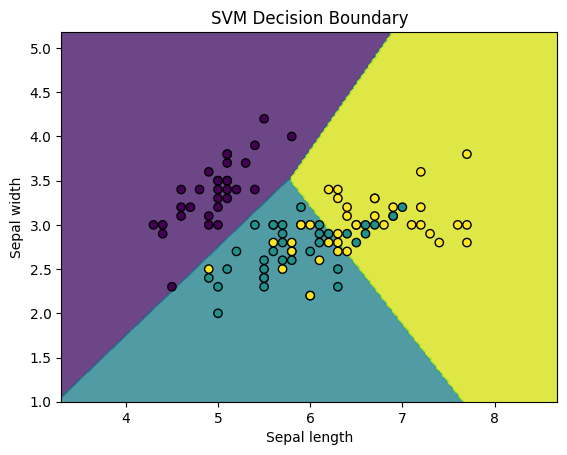

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

# 绘制决策边界
def plot_decision_boundary(X, y, model):
    h = .02  # 网格步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_decision_boundary(X_train, y_train, clf)